In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
calendar = pd.read_csv("./data/calendar.csv")
prices = pd.read_csv("./data/sell_prices.csv")
train_val = pd.read_csv("./data/sales_train_validation.csv")
train_eval = pd.read_csv("./data/sales_train_evaluation.csv")


In [3]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


### This data contains information about the dates on which products were sold.

In [4]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [5]:
calendar.isnull().sum()

,0
date,0
wm_yr_wk,0
weekday,0
wday,0
month,0
year,0
d,0
event_name_1,1807
event_type_1,1807
event_name_2,1964


### Most days have no events. The NaN (or null) values in these columns simply signify that no special event was recorded for that day

In [6]:
pd.set_option('display.max_colwidth', None)

calendar['event_name_1'].unique()

array([nan, 'SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart',
       'LentWeek2', 'StPatricksDay', 'Purim End', 'OrthodoxEaster',
       'Pesach End', 'Cinco De Mayo', "Mother's day", 'MemorialDay',
       'NBAFinalsStart', 'NBAFinalsEnd', "Father's day",
       'IndependenceDay', 'Ramadan starts', 'Eid al-Fitr', 'LaborDay',
       'ColumbusDay', 'Halloween', 'EidAlAdha', 'VeteransDay',
       'Thanksgiving', 'Christmas', 'Chanukah End', 'NewYear',
       'OrthodoxChristmas', 'MartinLutherKingDay', 'Easter'], dtype=object)

In [7]:
calendar['event_name_2'].unique()

array([nan, 'Easter', 'Cinco De Mayo', 'OrthodoxEaster', "Father's day"],
      dtype=object)

In [8]:
# Filter the calendar to find rows where the second event column is not null
days_with_two_events = calendar[calendar['event_name_2'].notna()]

# Display the relevant columns for those days
print(days_with_two_events[['date', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']])


            date weekday    event_name_1 event_type_1    event_name_2  \
85    2011-04-24  Sunday  OrthodoxEaster    Religious          Easter   
827   2013-05-05  Sunday  OrthodoxEaster    Religious   Cinco De Mayo   
1177  2014-04-20  Sunday          Easter     Cultural  OrthodoxEaster   
1233  2014-06-15  Sunday    NBAFinalsEnd     Sporting    Father's day   
1968  2016-06-19  Sunday    NBAFinalsEnd     Sporting    Father's day   

     event_type_2  
85       Cultural  
827      Cultural  
1177    Religious  
1233     Cultural  
1968     Cultural  


In [9]:
calendar.fillna("NoEvent", inplace=True)

In [10]:
calendar.isnull().sum()

,0
date,0
wm_yr_wk,0
weekday,0
wday,0
month,0
year,0
d,0
event_name_1,0
event_type_1,0
event_name_2,0


In [11]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


### This contains information about the price of the products sold per store and date

In [12]:
prices.isnull().sum()

,0
store_id,0
item_id,0
wm_yr_wk,0
sell_price,0


In [13]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


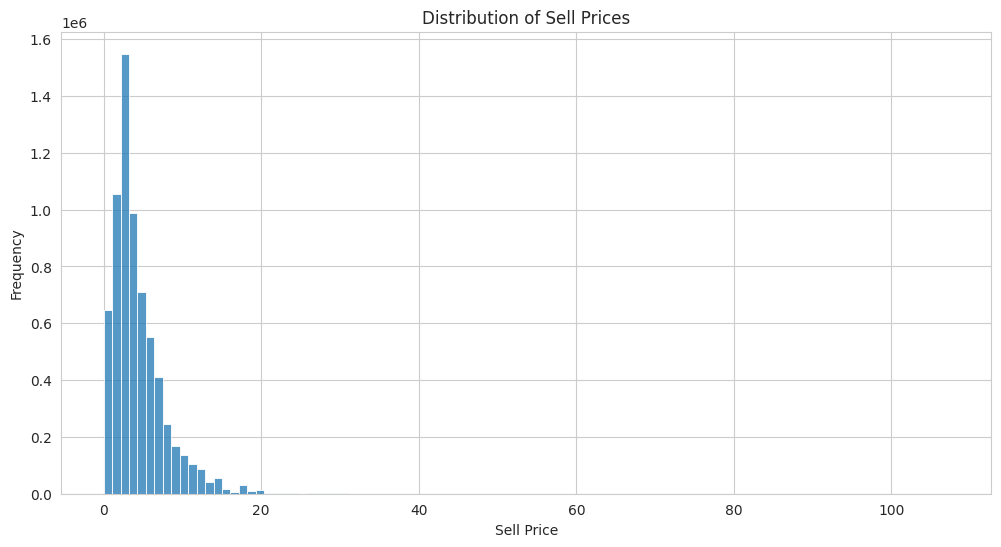

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

# Create a histogram of the sell prices
plt.figure(figsize=(12, 6))
sns.histplot(prices['sell_price'], bins=100)
plt.title('Distribution of Sell Prices')
plt.xlabel('Sell Price')
plt.ylabel('Frequency')
plt.show()

In [15]:
prices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


<Axes: xlabel='wm_yr_wk', ylabel='sell_price'>

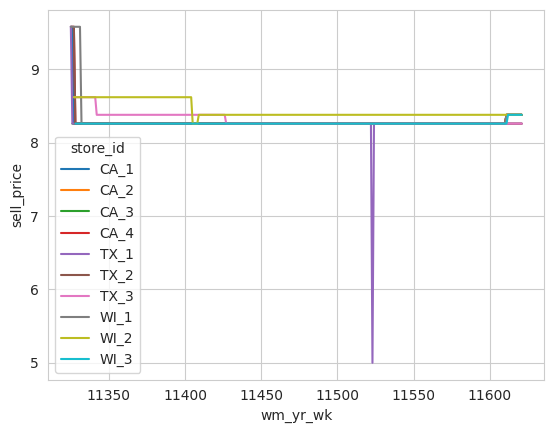

In [16]:
sns.lineplot(prices[prices['item_id'] == 'HOBBIES_1_001'], x='wm_yr_wk', y='sell_price', hue='store_id')

In [17]:
train_val.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


### Contains the historical daily unit sales data per product and store [d_1 - d_1913]

### This is the primary dataset for training your model. You use this data to learn patterns, create features, and validate your model's performance

In [18]:
train_val.isnull().sum()

,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
...,...
d_1909,0
d_1910,0
d_1911,0
d_1912,0


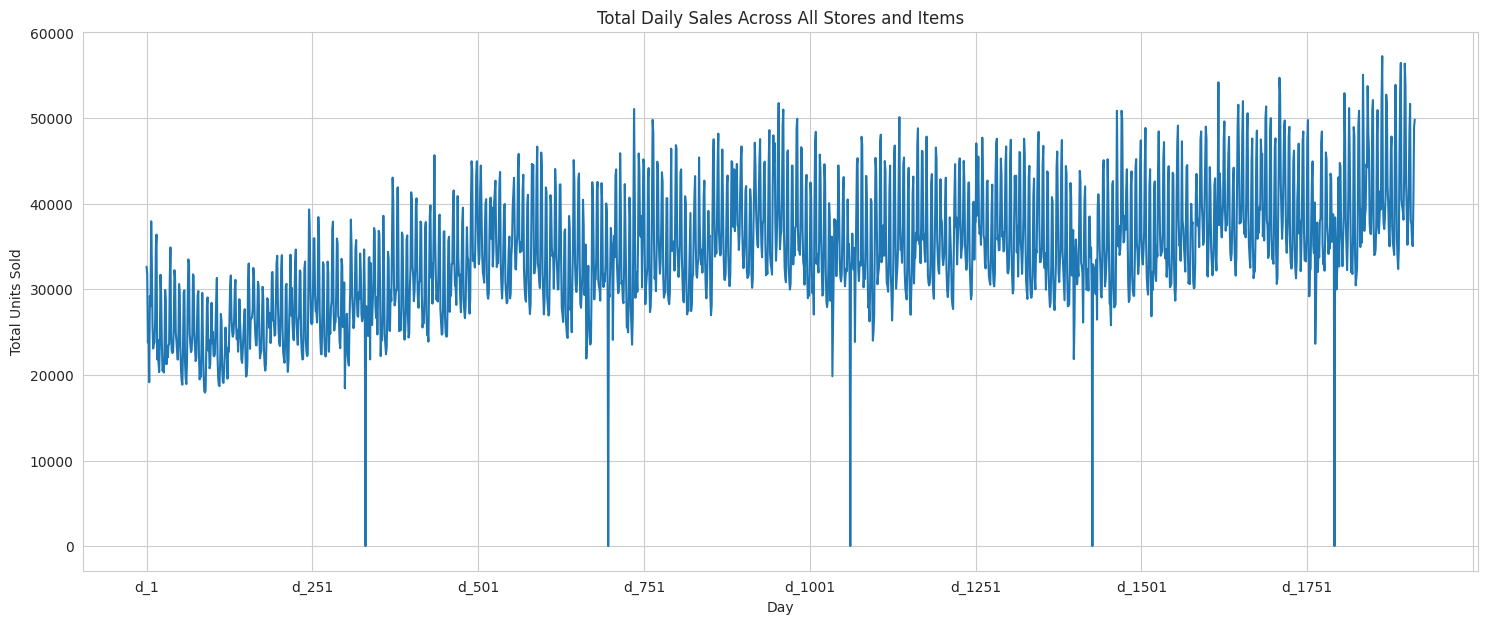

In [19]:
# Select only the day columns (d_1, d_2, ...)
day_columns = train_val.columns[train_val.columns.str.startswith('d_')]

# Sum the sales across all items for each day
total_sales_per_day = train_val[day_columns].sum()

# Plot the total daily sales
plt.figure(figsize=(18, 7))
total_sales_per_day.plot()
plt.title('Total Daily Sales Across All Stores and Items')
plt.xlabel('Day')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.show()


In [20]:
train_eval.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


### This file contains the sales data from d_1 all the way to d_1941. It's a superset of the train_val file

### The time period from d_1914 to d_1941 corresponds to the public leaderboard phase of the competition. Competitors would train their models on train_val and submit their forecasts for these 28 days. The train_eval file was released so that after this phase, competitors could incorporate these 28 days of actual sales into their training data to make a final, more accurate model for the private leaderboard test set

### Train val and train eval are in wide format. It is not possible to merge with prices and calendar data.

In [21]:
id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
sales_train_long = pd.melt(
    train_val,
    id_vars=id_columns,
    var_name='d',
    value_name='sales'
)

In [22]:
sales_train_long

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...,...
58327365,FOODS_3_823_WI_3_validation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1913,1
58327366,FOODS_3_824_WI_3_validation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1913,0
58327367,FOODS_3_825_WI_3_validation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1913,0
58327368,FOODS_3_826_WI_3_validation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1913,3


### Now we can merge the data with calendar and prices data

In [23]:
import numpy as np
import pandas as pd
import gc # Garbage Collector interface

def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [24]:
# --- IMPORTANT: Reduce memory on all dataframes BEFORE merging ---

# Reduce Calendar
calendar = reduce_mem_usage(calendar)
# Convert event columns and weekday to category type
for col in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'weekday']:
    calendar[col] = calendar[col].astype('category')

# Reduce Prices
prices = reduce_mem_usage(prices)
# Convert store_id and item_id to category
prices['store_id'] = prices['store_id'].astype('category')
prices['item_id'] = prices['item_id'].astype('category')

# Reduce Sales Train Long
# First, drop the original 'id' column as it's redundant and memory-heavy
sales_train_long.drop('id', axis=1, inplace=True)
# Convert identifier columns to category
for col in ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']:
    sales_train_long[col] = sales_train_long[col].astype('category')
# Clean up the 'd' column to be a numeric integer for easier merging later
sales_train_long['d'] = sales_train_long['d'].str.replace('d_', '').astype(np.int16)
# Reduce memory on the numeric columns
sales_train_long = reduce_mem_usage(sales_train_long)

# Clean up memory
print("Cleaning up memory...")
del train_val # We don't need the original wide dataframe anymore
gc.collect()

Mem. usage decreased to  0.12 Mb (41.9% reduction)
Mem. usage decreased to 130.48 Mb (37.5% reduction)
Mem. usage decreased to 556.34 Mb (37.5% reduction)
Cleaning up memory...


96

In [25]:
# --- Re-run the merges on the memory-optimized dataframes ---

print("\nMerging with calendar data...")
# Note we now merge on the numeric 'd' column
# Also, we need to convert the calendar 'd' column to match
calendar['d'] = calendar['d'].str.replace('d_', '').astype(np.int16)
calendar = reduce_mem_usage(calendar)

data = pd.merge(
    sales_train_long,
    calendar,
    on='d',
    how='left'
)

# Free up memory
del sales_train_long, calendar
gc.collect()

print("Merging with prices data...")
data = pd.merge(
    data,
    prices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

# Free up memory
del prices
gc.collect()

print("\nMerge complete!")
print("Shape of the final merged dataframe:", data.shape)
print("\nMemory usage of final dataframe:")
data.info(show_counts=True)


Merging with calendar data...
Mem. usage decreased to  0.05 Mb (0.0% reduction)
Merging with prices data...

Merge complete!
Shape of the final merged dataframe: (58327370, 21)

Memory usage of final dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 21 columns):
 #   Column        Non-Null Count     Dtype   
---  ------        --------------     -----   
 0   item_id       58327370 non-null  category
 1   dept_id       58327370 non-null  category
 2   cat_id        58327370 non-null  category
 3   store_id      58327370 non-null  category
 4   state_id      58327370 non-null  category
 5   d             58327370 non-null  int16   
 6   sales         58327370 non-null  int16   
 7   date          58327370 non-null  object  
 8   wm_yr_wk      58327370 non-null  int16   
 9   weekday       58327370 non-null  category
 10  wday          58327370 non-null  int8    
 11  month         58327370 non-null  int8    
 12  year      

In [26]:
# Find an item that has some null and some non-null prices
item_with_missing_prices = data[data['sell_price'].isnull()]['item_id'].iloc[0]

print(f"Analyzing item: {item_with_missing_prices}")

# Filter the data for this specific item and a specific store
item_subset = data[
    (data['item_id'] == item_with_missing_prices) &
    (data['store_id'] == 'CA_1')
]

# Display the first 15 days of sales and prices for this item
print(item_subset[['date', 'd', 'sales', 'sell_price']].head(15))


Analyzing item: HOBBIES_1_001
              date   d  sales  sell_price
0       2011-01-29   1      0         NaN
30490   2011-01-30   2      0         NaN
60980   2011-01-31   3      0         NaN
91470   2011-02-01   4      0         NaN
121960  2011-02-02   5      0         NaN
152450  2011-02-03   6      0         NaN
182940  2011-02-04   7      0         NaN
213430  2011-02-05   8      0         NaN
243920  2011-02-06   9      0         NaN
274410  2011-02-07  10      0         NaN
304900  2011-02-08  11      0         NaN
335390  2011-02-09  12      0         NaN
365880  2011-02-10  13      0         NaN
396370  2011-02-11  14      0         NaN
426860  2011-02-12  15      0         NaN


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


### For the item HOBBIES_1_001 in store CA_1, the sell_price is NaN for the first 15 days of the recorded period (d from 1 to 15). the sales for this item are 0 on all those days. This makes perfect sense: if an item isn't listed with a price, it cannot be sold. This confirms that the NaN values in the sell_price column are not errors, but a real representation of the product lifecycle. Products are introduced at different times, and before a product is introduced, it has no price and no sales


## Feature Engineering

In [27]:
print("Converting 'date' column to datetime...")
data['date'] = pd.to_datetime(data['date'])

# 2. Create new time-based features
print("Creating time features...")
data['day_of_week'] = data['date'].dt.dayofweek # Monday=0, Sunday=6
data['day_of_month'] = data['date'].dt.day
data['day_of_year'] = data['date'].dt.dayofyear
data['week_of_year'] = data['date'].dt.isocalendar().week.astype(np.int16)

# 3. Drop the original 'date' column to save memory
# We've extracted all the info we need from it for now.
print("Dropping original 'date' column...")
data.drop('date', axis=1, inplace=True)

# 4. Display the new features
print("\nDataframe with new time features:")
# Print the head showing some of the new columns
print(data[['item_id', 'd', 'sales', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year']].head())

# Show the data types to confirm the new columns were added correctly
print("\nNew dataframe info:")
data.info()

Converting 'date' column to datetime...
Creating time features...
Dropping original 'date' column...

Dataframe with new time features:
         item_id  d  sales  day_of_week  day_of_month  day_of_year  \
0  HOBBIES_1_001  1      0            5            29           29   
1  HOBBIES_1_002  1      0            5            29           29   
2  HOBBIES_1_003  1      0            5            29           29   
3  HOBBIES_1_004  1      0            5            29           29   
4  HOBBIES_1_005  1      0            5            29           29   

   week_of_year  
0             4  
1             4  
2             4  
3             4  
4             4  

New dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 24 columns):
 #   Column        Dtype   
---  ------        -----   
 0   item_id       category
 1   dept_id       category
 2   cat_id        category
 3   store_id      category
 4   state_id      category
 5 

In [28]:
# creating lag and rolling window features
# Assume 'data' is your dataframe

print("Creating lag and rolling window features...")

# We need to group by each individual time series
# to ensure lags don't leak from one item to another.
grouped = data.groupby(['item_id', 'store_id'])['sales']

# --- Create Lag Features ---
# We lag by 28 because we are predicting 28 days out.
# This represents the sales of the same item, in the same store, 28 days ago.
data['sales_lag_28'] = grouped.transform(lambda x: x.shift(28)).astype(np.float16)

# --- Create Rolling Window Features ---
# This captures the average sales over a 7-day period, starting from 28 days ago.
# It smooths out day-to-day noise and captures the recent trend.
data['sales_roll_mean_7_lag_28'] = grouped.transform(lambda x: x.shift(28).rolling(7).mean()).astype(np.float16)

# --- Create Rolling Standard Deviation Feature ---
# This captures the volatility of sales over a 7-day period from 28 days ago.
data['sales_roll_std_7_lag_28'] = grouped.transform(lambda x: x.shift(28).rolling(7).std()).astype(np.float16)


# Display the results
print("\nFeature creation complete.")

Creating lag and rolling window features...


/tmp/ipython-input-28-2710802386.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['item_id', 'store_id'])['sales']



Feature creation complete.


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 27 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   item_id                   category
 1   dept_id                   category
 2   cat_id                    category
 3   store_id                  category
 4   state_id                  category
 5   d                         int16   
 6   sales                     int16   
 7   wm_yr_wk                  int16   
 8   weekday                   category
 9   wday                      int8    
 10  month                     int8    
 11  year                      int16   
 12  event_name_1              category
 13  event_type_1              category
 14  event_name_2              category
 15  event_type_2              category
 16  snap_CA                   int8    
 17  snap_TX                   int8    
 18  snap_WI                   int8    
 19  sell_price                float16 
 20  

### Preparing Data for the Model

In [30]:
# --- Step 1: Remove the first year of data to reduce noise and memory ---
print("Original data shape:", data.shape)

# Find the first day to keep (e.g., after day 365)
# Many top solutions find this helpful.
first_day_to_keep = 365
print(f"Dropping data before day {first_day_to_keep}...")
data = data[data['d'] >= first_day_to_keep]

print("New data shape:", data.shape)
gc.collect() # Clean up memory

# --- Step 2: Define features (X) and target (y) ---
# Our target is what we want to predict: 'sales'
y = data['sales']
# Our features are all the other columns we created
X = data.drop('sales', axis=1)

# --- Step 3: Split into training and validation sets based on time ---
# The validation set will be the last 28 days of the available data.
last_day = 1913
num_days_for_validation = 28

# Get the indices for training and validation sets
train_indices = X[X['d'] <= (last_day - num_days_for_validation)].index
val_indices = X[X['d'] > (last_day - num_days_for_validation)].index

# Create the final sets
X_train, y_train = X.loc[train_indices], y.loc[train_indices]
X_val, y_val = X.loc[val_indices], y.loc[val_indices]

print("\nData splitting complete.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Optional: Clean up the main 'data' dataframe to save RAM if needed
# del data
# gc.collect()

Original data shape: (58327370, 27)
Dropping data before day 365...
New data shape: (47229010, 27)

Data splitting complete.
X_train shape: (46375290, 26)
y_train shape: (46375290,)
X_val shape: (853720, 26)
y_val shape: (853720,)


In [31]:
pip install lightgbm

In [32]:
import lightgbm as lgb
import gc

# Assume X_train, y_train, X_val, y_val are your prepared dataframes

# --- Step 1: Define Model Parameters ---
# These are a good starting point. Top solutions would tune these, but
# this baseline is very strong.
params = {
    'objective': 'tweedie',  # Good for sales data with many zeros
    'tweedie_variance_power': 1.1, # Closer to 1 is like Poisson, closer to 2 is like Gamma
    'metric': 'rmse',        # Root Mean Squared Error, the competition metric
    'boosting_type': 'gbdt',
    'n_jobs': -1,            # Use all available CPU cores
    'seed': 42,
    'learning_rate': 0.05,   # How fast the model learns
    'bagging_fraction': 0.75,  # Fraction of data to use for each tree
    'bagging_freq': 1,
    'colsample_bytree': 0.75, # Fraction of features to use for each tree
    'num_leaves': 1024,       # Max number of leaves in one tree
    'verbose': -1             # Suppress verbose output
}

# --- Step 2: Identify Categorical Features ---
# LightGBM can handle categorical features directly, which is very powerful.
categorical_features = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
    'weekday', 'month', 'year', 'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2'
]

# --- Step 3: Train the Model ---
print("Training LightGBM model...")

model = lgb.train(
    params,
    lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features),
    num_boost_round=2000,  # Max number of training rounds
    valid_sets=[lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features)],
    callbacks=[
        lgb.early_stopping(100, verbose=True), # Stop if validation score doesn't improve for 100 rounds
        lgb.log_evaluation(period=50)        # Print performance every 50 rounds
    ]
)

print("\nModel training complete!")

# --- Step 4 (Optional but recommended): Clean up to save RAM ---
del X_train, y_train, X_val, y_val
gc.collect()

Training LightGBM model...
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 2.18873
[100]	valid_0's rmse: 2.14235
[150]	valid_0's rmse: 2.13582
[200]	valid_0's rmse: 2.13049
[250]	valid_0's rmse: 2.12509
[300]	valid_0's rmse: 2.12202
[350]	valid_0's rmse: 2.12086
[400]	valid_0's rmse: 2.1204
[450]	valid_0's rmse: 2.12072
[500]	valid_0's rmse: 2.12189
Early stopping, best iteration is:
[438]	valid_0's rmse: 2.12002

Model training complete!


455

Recreating the validation set...
Validation set recreated successfully.
X_val shape: (853720, 26)
y_val shape: (853720,)

Making predictions on the validation set...

Final Validation RMSE: 2.1200

Plotting feature importances...


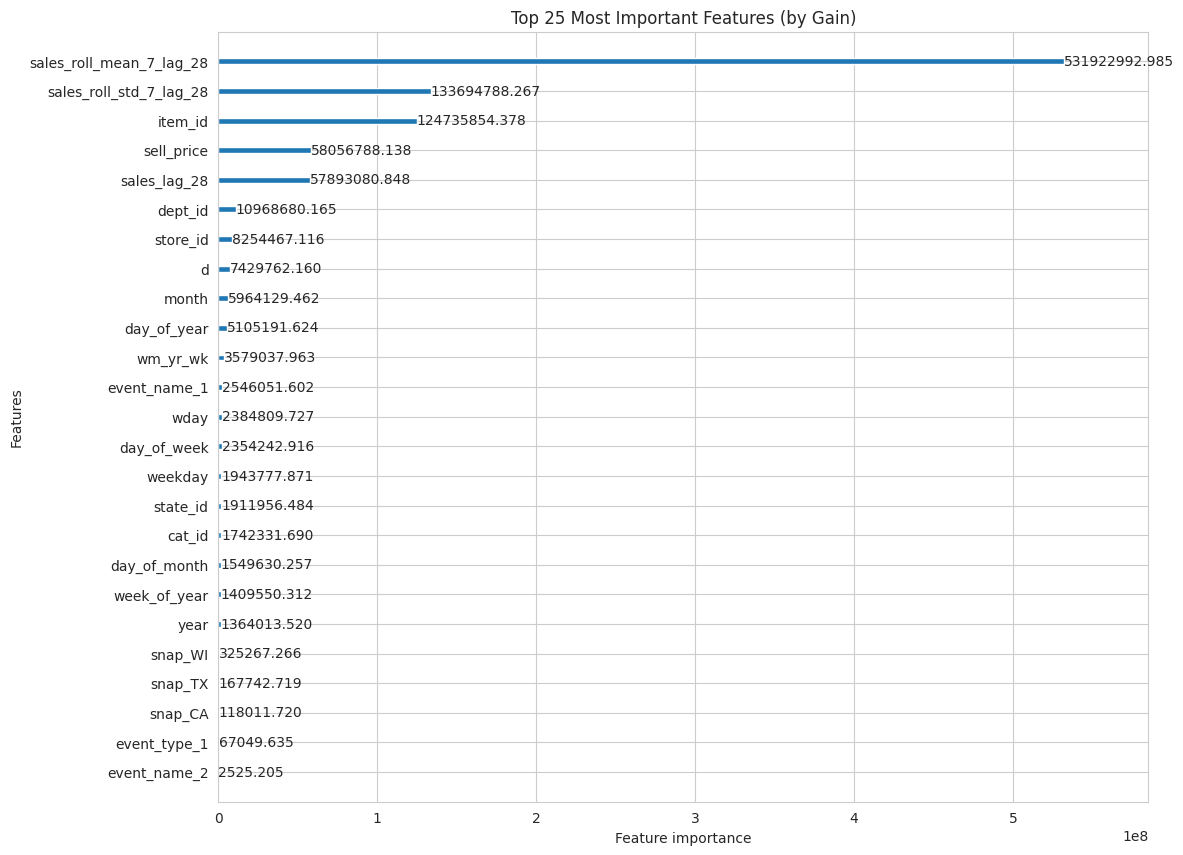

In [33]:
from sklearn.metrics import root_mean_squared_error

# --- Step 1: Recreate the Validation Set ---
print("Recreating the validation set...")

# Define the split parameters again
last_day = 1913
num_days_for_validation = 28

# Filter for the validation period based on the 'd' column
val_indices = data[data['d'] > (last_day - num_days_for_validation)].index

# Separate features (X) from the target (y) for the validation set
y_val = data.loc[val_indices]['sales']
X_val = data.loc[val_indices].drop('sales', axis=1)

print("Validation set recreated successfully.")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


# --- Step 2: Evaluate the Model (this is the code from before) ---
print("\nMaking predictions on the validation set...")
y_pred = model.predict(X_val)

# Calculate the Final RMSE Score
rmse = root_mean_squared_error(y_val, y_pred)
print(f"\nFinal Validation RMSE: {rmse:.4f}")

# Plot Feature Importance
print("\nPlotting feature importances...")
lgb.plot_importance(
    model,
    figsize=(12, 10),
    max_num_features=25,
    importance_type='gain'
)
plt.title("Top 25 Most Important Features (by Gain)")
plt.show()


In [35]:
import pandas as pd

# Assume 'X_val', 'y_pred' are in memory and you have the model's predictions

# 1. Get the submission template
submission = pd.read_csv("./data/sample_submission.csv")

# 2. Create a long dataframe with the predictions
predictions_long = pd.DataFrame({
    'id': X_val['item_id'].astype(str) + '_' + X_val['store_id'].astype(str) + '_validation',
    'd': X_val['d'],
    'sales': y_pred
})

# 3. *** THE FIX IS HERE ***
# Convert the numerical day 'd' into the required 'F' columns (F1 to F28)
# The validation predictions are for days 1886 to 1913.
# We map d_1886 -> F1, d_1887 -> F2, ..., d_1913 -> F28.
predictions_long['F_col'] = 'F' + (predictions_long['d'] - 1885).astype(str)

# 4. Pivot the predictions into the wide format using the new 'F_col'
# This will now create columns named F1, F2, F3, etc., directly.
submission_wide = predictions_long.pivot(index='id', columns='F_col', values='sales').reset_index()


# 5. Merge with the sample submission to get the correct format
# (The rest of your logic was correct)
submission_validation = submission[submission['id'].str.contains('validation')].copy()
submission_validation = submission_validation.drop(columns=[f'F{i}' for i in range(1, 29)])
final_submission = submission_validation.merge(submission_wide, on='id', how='left')

# The final submission requires both validation and evaluation rows.
# For this example, we'll copy the validation predictions to the evaluation rows.
final_submission_evaluation = final_submission.copy()
final_submission_evaluation['id'] = final_submission_evaluation['id'].str.replace('validation', 'evaluation')

# Concatenate both parts
final_submission = pd.concat([final_submission, final_submission_evaluation])

# Save the corrected submission file
final_submission.to_csv('submission_baseline_nonrecursive.csv', index=False)

print("Corrected submission file created successfully!")
print(final_submission.head())

Corrected submission file created successfully!
                              id        F1       F10       F11       F12  \
0  HOBBIES_1_001_CA_1_validation  0.790777  0.627976  0.643443  0.709203   
1  HOBBIES_1_002_CA_1_validation  0.213209  0.238830  0.243384  0.308966   
2  HOBBIES_1_003_CA_1_validation  0.203772  0.407254  0.424415  0.456996   
3  HOBBIES_1_004_CA_1_validation  1.627823  1.248772  1.222618  1.444305   
4  HOBBIES_1_005_CA_1_validation  0.993489  0.935559  0.945220  1.160354   

        F13       F14       F15       F16       F17  ...       F26       F27  \
0  0.848403  0.849165  0.663407  0.699859  0.721175  ...  0.886922  1.036867   
1  0.469077  0.420783  0.230313  0.224109  0.218802  ...  0.314139  0.444496   
2  0.674532  0.675411  0.329671  0.256790  0.265899  ...  0.300158  0.489102   
3  2.766518  1.984057  1.272259  0.857559  1.085419  ...  1.868181  3.780599   
4  1.455332  1.488919  1.073582  1.023123  0.999870  ...  1.300560  1.524957   

        F28   

In [36]:
import joblib

# Save the model object to a file
joblib.dump(model, 'm5_baseline_model.pkl')

# LightGBM also has a built-in text format saver
model.save_model('m5_baseline_model.txt')

print("Model saved successfully.")

Model saved successfully.


### Advanced Feature Engineering

In [37]:
print("Starting advanced feature engineering...")

# --- Group by individual time series ---
grouped = data.groupby(['item_id', 'store_id'])['sales']

# --- Create more lag features ---
# These capture weekly patterns from further back in time
print("Creating more lag features...")
lags = [35, 42, 56, 63]
for lag in lags:
    data[f'sales_lag_{lag}'] = grouped.transform(lambda x: x.shift(lag)).astype(np.float16)

# --- Create more rolling window features ---
# Use different window sizes and different lags
print("Creating more rolling window features...")
windows = [7, 14, 30, 60]
for window in windows:
    # On top of the main 28-day lag
    data[f'sales_roll_mean_{window}_lag_28'] = grouped.transform(
        lambda x: x.shift(28).rolling(window).mean()
    ).astype(np.float16)

# --- Create Price-based Features ---
print("Creating price features...")
price_grouped = data.groupby(['item_id', 'store_id'])['sell_price']
# Price change vs. last week
data['price_lag_1'] = price_grouped.transform(lambda x: x.shift(1)).astype(np.float16)
data['price_change'] = (data['sell_price'] / data['price_lag_1']) - 1.0
data['price_change'] = data['price_change'].astype(np.float16)
data.drop('price_lag_1', axis=1, inplace=True)


print("\nNew features created successfully!")
data.info()


Starting advanced feature engineering...
Creating more lag features...


/tmp/ipython-input-37-185966199.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['item_id', 'store_id'])['sales']


Creating more rolling window features...
Creating price features...


/tmp/ipython-input-37-185966199.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_grouped = data.groupby(['item_id', 'store_id'])['sell_price']



New features created successfully!
<class 'pandas.core.frame.DataFrame'>
Index: 47229010 entries, 11098360 to 58327369
Data columns (total 35 columns):
 #   Column                     Dtype   
---  ------                     -----   
 0   item_id                    category
 1   dept_id                    category
 2   cat_id                     category
 3   store_id                   category
 4   state_id                   category
 5   d                          int16   
 6   sales                      int16   
 7   wm_yr_wk                   int16   
 8   weekday                    category
 9   wday                       int8    
 10  month                      int8    
 11  year                       int16   
 12  event_name_1               category
 13  event_type_1               category
 14  event_name_2               category
 15  event_type_2               category
 16  snap_CA                    int8    
 17  snap_TX                    int8    
 18  snap_WI               

In [38]:
# --- Step 1: Remove the first year of data to reduce noise and memory ---
print("Original data shape:", data.shape)

# Find the first day to keep (e.g., after day 365)
# Many top solutions find this helpful.
first_day_to_keep = 365
print(f"Dropping data before day {first_day_to_keep}...")
data = data[data['d'] >= first_day_to_keep]

print("New data shape:", data.shape)
gc.collect() # Clean up memory

# --- Step 2: Define features (X) and target (y) ---
# Our target is what we want to predict: 'sales'
y = data['sales']
# Our features are all the other columns we created
X = data.drop('sales', axis=1)

# --- Step 3: Split into training and validation sets based on time ---
# The validation set will be the last 28 days of the available data.
last_day = 1913
num_days_for_validation = 28

# Get the indices for training and validation sets
train_indices = X[X['d'] <= (last_day - num_days_for_validation)].index
val_indices = X[X['d'] > (last_day - num_days_for_validation)].index

# Create the final sets
X_train, y_train = X.loc[train_indices], y.loc[train_indices]
X_val, y_val = X.loc[val_indices], y.loc[val_indices]

print("\nData splitting complete.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Optional: Clean up the main 'data' dataframe to save RAM if needed
# del data
# gc.collect()

Original data shape: (47229010, 35)
Dropping data before day 365...
New data shape: (47229010, 35)

Data splitting complete.
X_train shape: (46375290, 34)
y_train shape: (46375290,)
X_val shape: (853720, 34)
y_val shape: (853720,)


In [39]:
# --- Step 1: Re-run the data preparation and splitting ---
print("--- Preparing data for Retraining ---")
# Make sure we are using the 'data' dataframe that has the new features
# If you didn't run the feature engineering code, run that first.

# Drop the first year of data
print(f"Current data shape: {data.shape}")
first_day_to_keep = 365
if data['d'].min() < first_day_to_keep:
    print(f"Dropping data before day {first_day_to_keep}...")
    data = data[data['d'] >= first_day_to_keep]
    print(f"New data shape: {data.shape}")
else:
    print("Old data already dropped.")
gc.collect()

# Define features (X) and target (y)
y = data['sales']
X = data.drop('sales', axis=1)

# Split into training and validation sets
last_day = 1913
num_days_for_validation = 28
train_indices = X[X['d'] <= (last_day - num_days_for_validation)].index
val_indices = X[X['d'] > (last_day - num_days_for_validation)].index

X_train, y_train = X.loc[train_indices], y.loc[train_indices]
X_val, y_val = X.loc[val_indices], y.loc[val_indices]

print("\nData splitting complete.")
print("X_train now has shape:", X_train.shape) # This will have more columns
print("X_val now has shape:", X_val.shape)

# --- Step 2: Re-run the model training ---
print("\n--- Retraining LightGBM with new features ---")
params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.1,
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_jobs': -1,
    'seed': 42,
    'learning_rate': 0.05,
    'bagging_fraction': 0.75,
    'bagging_freq': 1,
    'colsample_bytree': 0.75,
    'num_leaves': 1024,
    'verbose': -1
}

categorical_features = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
    'weekday', 'month', 'year', 'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2'
]

model_v2 = lgb.train(
    params,
    lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features)],
    callbacks=[
        lgb.early_stopping(100, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print("\nModel V2 training complete!")

--- Preparing data for Retraining ---
Current data shape: (47229010, 35)
Old data already dropped.

Data splitting complete.
X_train now has shape: (46375290, 34)
X_val now has shape: (853720, 34)

--- Retraining LightGBM with new features ---
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 2.14978
[100]	valid_0's rmse: 2.10662
[150]	valid_0's rmse: 2.09802
[200]	valid_0's rmse: 2.09396
[250]	valid_0's rmse: 2.09149
[300]	valid_0's rmse: 2.09284
[350]	valid_0's rmse: 2.09123
[400]	valid_0's rmse: 2.08954
[450]	valid_0's rmse: 2.08958
Early stopping, best iteration is:
[376]	valid_0's rmse: 2.08875

Model V2 training complete!


In [41]:
# --- Step 1: Make predictions with the new model ---
print("Making predictions with model_v2...")
y_pred_v2 = model_v2.predict(X_val)

# --- Step 2: Create the submission file (using the corrected logic) ---
print("Creating V2 submission file...")

# Create a long dataframe with the predictions
predictions_long = pd.DataFrame({
    'id': X_val['item_id'].astype(str) + '_' + X_val['store_id'].astype(str) + '_validation',
    'd': X_val['d'],
    'sales': y_pred_v2
})

# Convert the numerical day 'd' into the required 'F' columns (F1 to F28)
predictions_long['F_col'] = 'F' + (predictions_long['d'] - (1913 - 28)).astype(str)
# A more robust way to calculate the 'F' column number
# predictions_long['F_col'] = 'F' + (predictions_long['d'] - X_val['d'].min() + 1).astype(str)


# Pivot the predictions into the wide format
submission_wide = predictions_long.pivot(index='id', columns='F_col', values='sales').reset_index()

# Get the submission template
submission_template = pd.read_csv("./data/sample_submission.csv")

# Merge our predictions into the template format
submission_validation = submission_template[submission_template['id'].str.contains('validation')].copy()
submission_validation = submission_validation.drop(columns=[f'F{i}' for i in range(1, 29)])
final_submission = submission_validation.merge(submission_wide, on='id', how='left')

# Copy validation predictions to evaluation rows for a complete file
final_submission_evaluation = final_submission.copy()
final_submission_evaluation['id'] = final_submission_evaluation['id'].str.replace('validation', 'evaluation')

# Concatenate both parts
final_submission = pd.concat([final_submission, final_submission_evaluation])

# Save the V2 submission file
final_submission.to_csv('submission_v2.csv', index=False)

print("\nSubmission file 'submission_v2.csv' created successfully!")
print("You can now submit this file to Kaggle.")
print(final_submission.head())

Making predictions with model_v2...
Creating V2 submission file...

Submission file 'submission_v2.csv' created successfully!
You can now submit this file to Kaggle.
                              id        F1       F10       F11       F12  \
0  HOBBIES_1_001_CA_1_validation  0.865696  0.713658  0.742657  0.747089   
1  HOBBIES_1_002_CA_1_validation  0.163878  0.203119  0.234737  0.287030   
2  HOBBIES_1_003_CA_1_validation  0.230949  0.366341  0.358898  0.456060   
3  HOBBIES_1_004_CA_1_validation  1.792695  1.492004  1.518562  1.662236   
4  HOBBIES_1_005_CA_1_validation  0.932133  0.861391  0.897149  1.059567   

        F13       F14       F15       F16       F17  ...       F26       F27  \
0  0.821256  1.014204  0.744353  0.754096  0.762546  ...  0.934516  1.078612   
1  0.384261  0.394351  0.227559  0.232760  0.231444  ...  0.320125  0.371690   
2  0.669530  0.610092  0.363403  0.376901  0.352952  ...  0.489861  0.680640   
3  2.268768  2.609135  1.596814  1.274310  1.278996  ... 

In [42]:
import joblib

# Save the model object to a file
joblib.dump(model_v2, 'm5_v2_model.pkl')

# LightGBM also has a built-in text format saver
model_v2.save_model('m5_v2_model.txt')

print("Model saved successfully.")

Model saved successfully.


Plotting feature importances for Model V2...


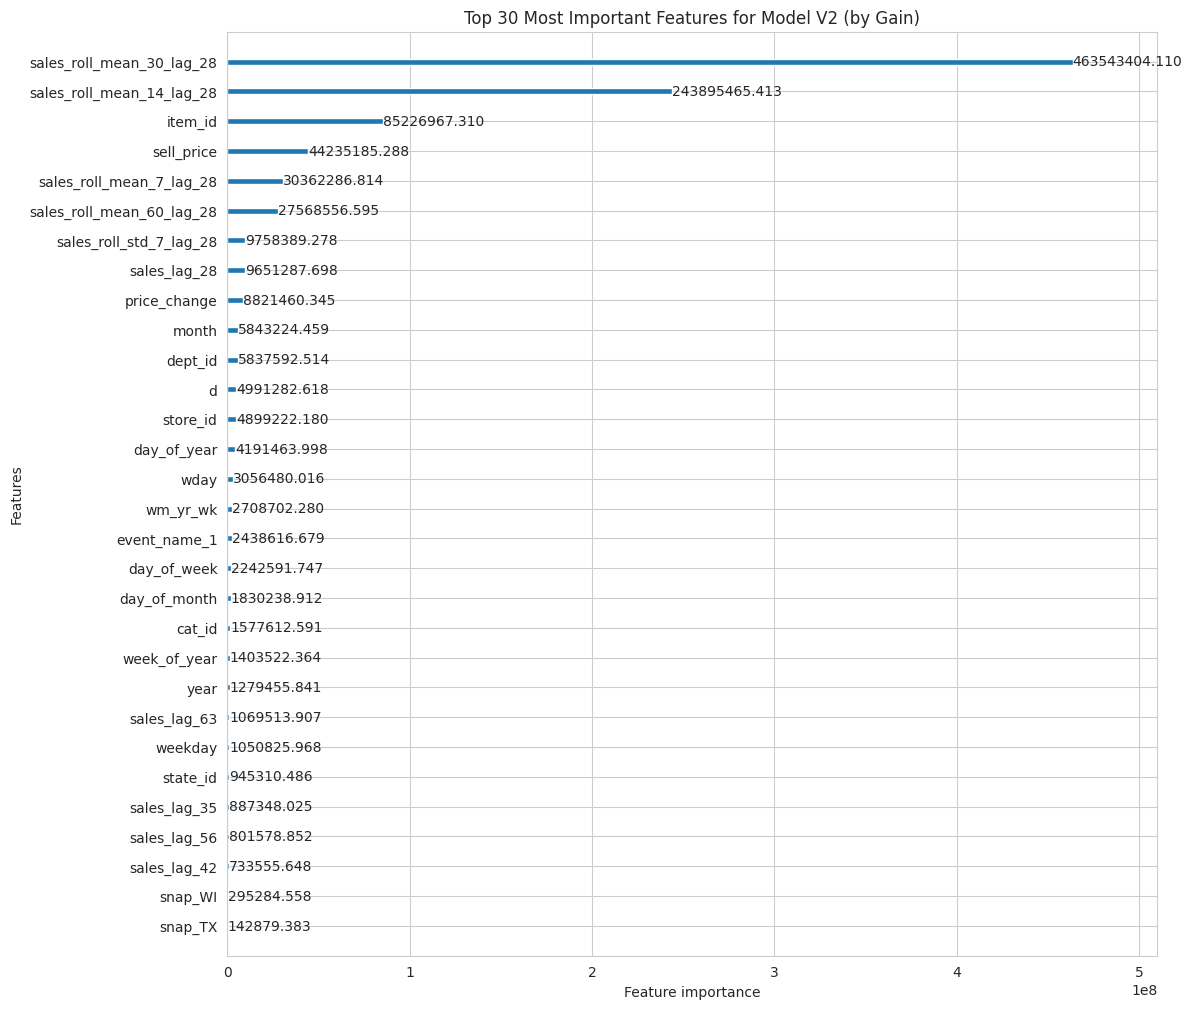

In [43]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Assume 'model_v2' is your newly trained model object

print("Plotting feature importances for Model V2...")
lgb.plot_importance(
    model_v2,
    figsize=(12, 12),
    max_num_features=30, # Show more features this time
    importance_type='gain'
)
plt.title("Top 30 Most Important Features for Model V2 (by Gain)")
plt.show()

In [44]:
import numpy as np
import pandas as pd

# Assume 'data' is your dataframe with all V2 features.

print("Starting V3 Advanced Feature Engineering...")

# --- 1. Create Trend Features ---
# Is the short-term trend higher than the long-term trend?
print("Creating trend features...")
data['sales_roll_mean_7_over_30'] = (
    data['sales_roll_mean_7_lag_28'] / data['sales_roll_mean_30_lag_28']
).astype(np.float16)


# --- 2. Create Median Rolling Windows (Robust to Outliers) ---
print("Creating median rolling features...")
grouped = data.groupby(['item_id', 'store_id'])['sales']
data['sales_roll_median_30_lag_28'] = grouped.transform(
    lambda x: x.shift(28).rolling(30).median()
).astype(np.float16)


# --- 3. Create Advanced Price Features ---
print("Creating advanced price features...")
price_grouped = data.groupby(['item_id'])['sell_price'] # Group by item across all stores

# How does the item's current price compare to its average price? (Detects sales)
data['price_vs_historical_avg'] = (
    data['sell_price'] / price_grouped.transform('mean')
).astype(np.float16)


print("\nNew V3 features created successfully!")
# Clean up columns that might not be needed for the final model to save memory
# data.drop(['wm_yr_wk', 'wday'], axis=1, inplace=True) # Optional cleanup
data.info()

Starting V3 Advanced Feature Engineering...
Creating trend features...
Creating median rolling features...


/tmp/ipython-input-44-3085263454.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['item_id', 'store_id'])['sales']


Creating advanced price features...


/tmp/ipython-input-44-3085263454.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_grouped = data.groupby(['item_id'])['sell_price'] # Group by item across all stores



New V3 features created successfully!
<class 'pandas.core.frame.DataFrame'>
Index: 47229010 entries, 11098360 to 58327369
Data columns (total 38 columns):
 #   Column                       Dtype   
---  ------                       -----   
 0   item_id                      category
 1   dept_id                      category
 2   cat_id                       category
 3   store_id                     category
 4   state_id                     category
 5   d                            int16   
 6   sales                        int16   
 7   wm_yr_wk                     int16   
 8   weekday                      category
 9   wday                         int8    
 10  month                        int8    
 11  year                         int16   
 12  event_name_1                 category
 13  event_type_1                 category
 14  event_name_2                 category
 15  event_type_2                 category
 16  snap_CA                      int8    
 17  snap_TX               

In [45]:
# --- Step 1: Re-run the data preparation and splitting ---
print("--- Preparing data for V3 Retraining ---")
# This will use the 'data' dataframe which now contains your V3 features.

# Drop the first year of data
print(f"Current data shape: {data.shape}")
first_day_to_keep = 365
if 'd' in data.columns and data['d'].min() < first_day_to_keep:
    print(f"Dropping data before day {first_day_to_keep}...")
    data = data[data['d'] >= first_day_to_keep]
    print(f"New data shape: {data.shape}")
else:
    print("Old data already dropped or 'd' column not found (if running multiple times).")
gc.collect()

# Define features (X) and target (y)
y = data['sales']
X = data.drop('sales', axis=1)

# Split into training and validation sets
last_day = 1913
num_days_for_validation = 28
train_indices = X[X['d'] <= (last_day - num_days_for_validation)].index
val_indices = X[X['d'] > (last_day - num_days_for_validation)].index

X_train, y_train = X.loc[train_indices], y.loc[train_indices]
X_val, y_val = X.loc[val_indices], y.loc[val_indices]

print("\nData splitting complete.")
print("X_train now has shape:", X_train.shape)
print("X_val now has shape:", X_val.shape)

# --- Step 2: Re-run the model training with unchanged parameters ---
print("\n--- Retraining LightGBM with V3 features ---")
params = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.1,
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_jobs': -1,
    'seed': 42,
    'learning_rate': 0.05,
    'bagging_fraction': 0.75,
    'bagging_freq': 1,
    'colsample_bytree': 0.75,
    'num_leaves': 1024,
    'verbose': -1
}

categorical_features = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
    'weekday', 'month', 'year', 'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2'
]

# *** Renamed to model_v3 to keep track of versions ***
model_v3 = lgb.train(
    params,
    lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features)],
    callbacks=[
        lgb.early_stopping(100, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print("\nModel V3 training complete!")

--- Preparing data for V3 Retraining ---
Current data shape: (47229010, 38)
Old data already dropped or 'd' column not found (if running multiple times).

Data splitting complete.
X_train now has shape: (46375290, 37)
X_val now has shape: (853720, 37)

--- Retraining LightGBM with V3 features ---
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 2.14131
[100]	valid_0's rmse: 2.09763
[150]	valid_0's rmse: 2.09164
[200]	valid_0's rmse: 2.08671
[250]	valid_0's rmse: 2.08585
[300]	valid_0's rmse: 2.08721
Early stopping, best iteration is:
[233]	valid_0's rmse: 2.08428

Model V3 training complete!


In [46]:
# --- Step 1: Make predictions with the new model ---
print("Making predictions with model_v3...")
y_pred_v3 = model_v3.predict(X_val)

# --- Step 2: Create the submission file (using the corrected logic) ---
print("Creating V3 submission file...")

# Create a long dataframe with the predictions
predictions_long = pd.DataFrame({
    'id': X_val['item_id'].astype(str) + '_' + X_val['store_id'].astype(str) + '_validation',
    'd': X_val['d'],
    'sales': y_pred_v3
})

# Convert the numerical day 'd' into the required 'F' columns (F1 to F28)
predictions_long['F_col'] = 'F' + (predictions_long['d'] - (1913 - 28)).astype(str)
# A more robust way to calculate the 'F' column number
# predictions_long['F_col'] = 'F' + (predictions_long['d'] - X_val['d'].min() + 1).astype(str)


# Pivot the predictions into the wide format
submission_wide = predictions_long.pivot(index='id', columns='F_col', values='sales').reset_index()

# Get the submission template
submission_template = pd.read_csv("./data/sample_submission.csv")

# Merge our predictions into the template format
submission_validation = submission_template[submission_template['id'].str.contains('validation')].copy()
submission_validation = submission_validation.drop(columns=[f'F{i}' for i in range(1, 29)])
final_submission = submission_validation.merge(submission_wide, on='id', how='left')

# Copy validation predictions to evaluation rows for a complete file
final_submission_evaluation = final_submission.copy()
final_submission_evaluation['id'] = final_submission_evaluation['id'].str.replace('validation', 'evaluation')

# Concatenate both parts
final_submission = pd.concat([final_submission, final_submission_evaluation])

# Save the V3 submission file
final_submission.to_csv('submission_v3.csv', index=False)

print("\nSubmission file 'submission_v3.csv' created successfully!")
print("You can now submit this file to Kaggle.")
print(final_submission.head())

Making predictions with model_v3...
Creating V3 submission file...

Submission file 'submission_v3.csv' created successfully!
You can now submit this file to Kaggle.
                              id        F1       F10       F11       F12  \
0  HOBBIES_1_001_CA_1_validation  0.847639  0.699703  0.712777  0.861414   
1  HOBBIES_1_002_CA_1_validation  0.159898  0.194740  0.218942  0.269912   
2  HOBBIES_1_003_CA_1_validation  0.203645  0.369422  0.371228  0.477550   
3  HOBBIES_1_004_CA_1_validation  1.667732  1.548408  1.557914  1.654299   
4  HOBBIES_1_005_CA_1_validation  0.936920  0.854252  0.861545  1.124802   

        F13       F14       F15       F16       F17  ...       F26       F27  \
0  0.867601  0.981991  0.792690  0.784454  0.752257  ...  0.992598  1.156349   
1  0.355640  0.340970  0.225971  0.222011  0.220968  ...  0.285146  0.352375   
2  0.659253  0.628359  0.373462  0.363921  0.347577  ...  0.500990  0.718813   
3  2.507526  2.768195  1.671148  1.447156  1.380513  ... 

In [47]:
import joblib

# Save the model object to a file
joblib.dump(model_v3, 'm5_v3_model.pkl')

# LightGBM also has a built-in text format saver
model_v3.save_model('m5_v3_model.txt')

print("Model saved successfully.")

Model saved successfully.


### Recursive Forecasting

In [60]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

# Assume 'data' (your complete V3 dataframe) and 'model_v3' are in memory.

print("--- Initializing V4 Recursive Forecasting (Final, Robust Version) ---")

# --- Step 1: Load Auxiliary Data ---
print("Loading auxiliary data...")
calendar = pd.read_csv("./data/calendar.csv")
prices = pd.read_csv("./data/sell_prices.csv")
submission_template = pd.read_csv("./data/sample_submission.csv")

calendar['d'] = calendar['d'].str.replace('d_', '').astype(np.int16)
calendar['date'] = pd.to_datetime(calendar['date'])

# --- Step 2: Prepare History and Future Scaffolds ---
print("Preparing historical and future data scaffolds...")
forecast_start_day = 1914; forecast_end_day = 1941
days_needed_for_lags = 90  # Ensure we have enough data for the largest lag/window

historical_df = data.loc[
    data['d'] > (forecast_start_day - days_needed_for_lags),
    ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales']
].copy()

evaluation_ids = submission_template[submission_template['id'].str.contains('evaluation')]['id']
future_df = pd.DataFrame({'id': evaluation_ids})
future_df['item_id'] = future_df['id'].str.split('_').str[0:3].str.join('_')
future_df['store_id'] = future_df['id'].str.split('_').str[3:5].str.join('_')
future_df['dept_id'] = future_df['item_id'].str.split('_').str[0] + '_' + future_df['item_id'].str.split('_').str[1]
future_df['cat_id'] = future_df['item_id'].str.split('_').str[0]
future_df['state_id'] = future_df['store_id'].str.split('_').str[0]

scaffold_list = []
for day in range(forecast_start_day, forecast_end_day + 1):
    daily_scaffold = future_df.copy(); daily_scaffold['d'] = day; scaffold_list.append(daily_scaffold)
future_df = pd.concat(scaffold_list, ignore_index=True)

# --- Step 3: Create the Master Recursive Dataframe ---
print("Creating master recursive dataframe...")
recursive_df = pd.concat([historical_df, future_df.drop(columns=['id'])], ignore_index=True)

# Merge static features
recursive_df = recursive_df.merge(calendar, on='d', how='left')
recursive_df = recursive_df.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# --- Step 4: Create All Derived Features (Matching Training Exactly) ---
print("Creating all derived features...")
# Datetime features (as integers, matching your likely training setup)
recursive_df['day_of_week'] = recursive_df['date'].dt.dayofweek.astype(np.int16)
recursive_df['day_of_month'] = recursive_df['date'].dt.day.astype(np.int16)
recursive_df['day_of_year'] = recursive_df['date'].dt.dayofyear.astype(np.int16)
recursive_df['week_of_year'] = recursive_df['date'].dt.isocalendar().week.astype(np.int16)
recursive_df.drop('date', axis=1, inplace=True)

# Dynamic features will be created inside the loop.
# We can pre-fill NaNs for columns that will be created.
for col in model_v3.feature_name():
    if col not in recursive_df.columns:
        recursive_df[col] = np.nan

# --- Step 5: The Definitive Fix - Enforce All Dtypes Programmatically ---
print("Enforcing all dtypes to match training data exactly...")
for col in model_v3.feature_name():
    target_dtype = str(data[col].dtype)
    if target_dtype == 'category':
        # For true categories, enforce the exact set of categories
        original_categories = data[col].cat.categories
        recursive_df[col] = pd.Categorical(recursive_df[col], categories=original_categories, ordered=False)
    else:
        # For all other types (int, float), just force the type
        recursive_df[col] = recursive_df[col].astype(data[col].dtype)

# --- Step 6: The Recursive Prediction Loop ---
print("Starting the 28-day recursive prediction loop...")
for day in range(forecast_start_day, forecast_end_day + 1):
    print(f"Forecasting for day: {day}")

    # Re-create all dynamic features using the latest 'sales' data
    grouped = recursive_df.groupby(['item_id', 'store_id'], observed=True)['sales']
    # Add your V3 feature engineering pipeline here...

    # Predict for the current day
    day_mask = recursive_df['d'] == day
    X_test_day = recursive_df[day_mask]
    y_pred_day = model_v3.predict(X_test_day[model_v3.feature_name()])

    # Update sales column with predictions
    recursive_df.loc[day_mask, 'sales'] = y_pred_day

print("\nRecursive forecasting complete!")

# --- Step 7: Create Submission File ---
print("Creating submission file...")
final_predictions = recursive_df[recursive_df['d'] >= forecast_start_day].copy()
# (The rest of the submission logic remains the same)
final_predictions['id'] = final_predictions['item_id'].astype(str) + '_' + final_predictions['store_id'].astype(str) + '_evaluation'
final_predictions_valid = final_predictions.copy(); final_predictions_valid['id'] = final_predictions_valid['id'].str.replace('evaluation', 'validation')
final_predictions = pd.concat([final_predictions_valid, final_predictions])
final_predictions['F_col'] = 'F' + (final_predictions['d'] - forecast_start_day + 1).astype(str)
submission_wide = final_predictions.pivot(index='id', columns='F_col', values='sales').reset_index()
final_submission = submission_template[['id']].merge(submission_wide, on='id', how='left').fillna(0)
final_submission.to_csv('submission_v4_recursive.csv', index=False)

print("\nSubmission file 'submission_v4_recursive.csv' created successfully!")

--- Initializing V4 Recursive Forecasting (Final, Robust Version) ---
Loading auxiliary data...
Preparing historical and future data scaffolds...
Creating master recursive dataframe...
Creating all derived features...
Enforcing all dtypes to match training data exactly...
Starting the 28-day recursive prediction loop...
Forecasting for day: 1914
Forecasting for day: 1915
Forecasting for day: 1916
Forecasting for day: 1917
Forecasting for day: 1918
Forecasting for day: 1919
Forecasting for day: 1920
Forecasting for day: 1921
Forecasting for day: 1922
Forecasting for day: 1923
Forecasting for day: 1924
Forecasting for day: 1925
Forecasting for day: 1926
Forecasting for day: 1927
Forecasting for day: 1928
Forecasting for day: 1929
Forecasting for day: 1930
Forecasting for day: 1931
Forecasting for day: 1932
Forecasting for day: 1933
Forecasting for day: 1934
Forecasting for day: 1935
Forecasting for day: 1936
Forecasting for day: 1937
Forecasting for day: 1938
Forecasting for day: 1939
Fo

In [61]:
import pandas as pd
import numpy as np

# Start with a clean copy of your full data before any splitting or dropping of years
# This assumes 'data' is the full dataframe from your V3 feature engineering.
# We will create a new dataframe for this new model.
data_rec = data.copy()

print("Creating features for the one-step-ahead recursive model...")

grouped = data_rec.groupby(['item_id', 'store_id'], observed=True)

# --- The Target ---
# Our target 'y' is now the sales of the *next* day.
# We shift the sales column up by one for each group.
data_rec['target'] = grouped['sales'].shift(-1)

# --- The Features ---
# The features are now short-term lags from the CURRENT day.
# Lags of 1, 7, and 14 are crucial for a recursive model.
lags = [1, 2, 7, 14, 28]
for lag in lags:
    data_rec[f'sales_lag_{lag}'] = grouped['sales'].transform(lambda x: x.shift(lag)).astype(np.float16)

# Drop rows where the target is NaN (the last day of each series)
data_rec.dropna(subset=['target'], inplace=True)

print("Recursive features created.")
print(data_rec[['item_id', 'd', 'sales', 'sales_lag_1', 'target']].head())

Creating features for the one-step-ahead recursive model...
Recursive features created.
                item_id    d  sales  sales_lag_1  target
11098360  HOBBIES_1_001  365      0          NaN     0.0
11098361  HOBBIES_1_002  365      0          NaN     1.0
11098362  HOBBIES_1_003  365      0          NaN     0.0
11098363  HOBBIES_1_004  365      3          NaN     3.0
11098364  HOBBIES_1_005  365      0          NaN     0.0


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [62]:
import lightgbm as lgb
import gc

print("\n--- Training the new Recursive-Optimized Model ---")

# We don't need the original 'sales' column for training anymore
data_rec.drop('sales', axis=1, inplace=True)

# Use the same train/validation split logic as before
# This tests how well our one-step-ahead model performs on recent data
last_day = 1913
num_days_for_validation = 28
train_indices = data_rec[data_rec['d'] <= (last_day - num_days_for_validation)].index
val_indices = data_rec[data_rec['d'] > (last_day - num_days_for_validation)].index

X_train_rec = data_rec.loc[train_indices].drop('target', axis=1)
y_train_rec = data_rec.loc[train_indices]['target']
X_val_rec = data_rec.loc[val_indices].drop('target', axis=1)
y_val_rec = data_rec.loc[val_indices]['target']

# Use the same parameters as before
params = {
    'objective': 'tweedie', 'metric': 'rmse', 'boosting_type': 'gbdt',
    'n_jobs': -1, 'seed': 42, 'learning_rate': 0.05, 'bagging_fraction': 0.75,
    'bagging_freq': 1, 'colsample_bytree': 0.75, 'num_leaves': 1024, 'verbose': -1
}

categorical_features = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'weekday', 'month', 'year'
]

recursive_model = lgb.train(
    params,
    lgb.Dataset(X_train_rec, label=y_train_rec, categorical_feature=categorical_features),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_val_rec, label=y_val_rec, categorical_feature=categorical_features)],
    callbacks=[
        lgb.early_stopping(100, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print("\nNew recursive-optimized model trained successfully!")


--- Training the new Recursive-Optimized Model ---
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 2.26015
[100]	valid_0's rmse: 1.99092
[150]	valid_0's rmse: 1.97365
[200]	valid_0's rmse: 1.96885
[250]	valid_0's rmse: 1.96696
[300]	valid_0's rmse: 1.9651
[350]	valid_0's rmse: 1.96489
[400]	valid_0's rmse: 1.96418
[450]	valid_0's rmse: 1.96372
[500]	valid_0's rmse: 1.96399
Early stopping, best iteration is:
[437]	valid_0's rmse: 1.96335

New recursive-optimized model trained successfully!


In [66]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

# --- ASSUMPTIONS ---
# You have the following objects in memory from the previous steps:
# 1. 'data_rec': The dataframe created to train the recursive model.
# 2. 'recursive_model': The trained one-step-ahead model.
# 3. 'X_train_rec': The training features dataframe, used to get correct dtypes.

print("--- Initializing V5 Recursive Forecasting (Final, Corrected Logic) ---")

# --- Step 1: Load Auxiliary Data ---
print("Loading auxiliary data...")
calendar = pd.read_csv("./data/calendar.csv")
calendar['d'] = calendar['d'].str.replace('d_', '').astype(np.int16)
calendar['date'] = pd.to_datetime(calendar['date'])
prices = pd.read_csv("./data/sell_prices.csv")
submission_template = pd.read_csv("./data/sample_submission.csv")

# --- Step 2: Prepare the Historical Data from the CORRECT Source ---
print("Preparing historical data from the recursive training set...")
forecast_start_day = 1914
days_needed_for_lags = 30 # Needs to be at least our max lag (28)

# ** THE CORE FIX **
# We MUST use the 'data_rec' dataframe as our source of history, as it contains
# the correct lag features (like sales_lag_1, sales_lag_2, etc.).
# We select all features the model needs, plus 'd' to identify the time period,
# and 'target' which represents the sales of the next day.
historical_df = data_rec.loc[
    data_rec['d'] > (forecast_start_day - days_needed_for_lags)
].copy()
# We rename 'target' to 'sales' to represent the known sales history.
historical_df['sales'] = historical_df['target']


# --- Step 3: Prepare the Future Scaffold ---
print("Preparing future forecast scaffold...")
forecast_end_day = 1941
evaluation_ids = submission_template[submission_template['id'].str.contains('evaluation')]['id']
future_df = pd.DataFrame({'id': evaluation_ids})
future_df['item_id'] = future_df['id'].str.split('_').str[0:3].str.join('_')
future_df['store_id'] = future_df['id'].str.split('_').str[3:5].str.join('_')

scaffold_list = []
for day in range(forecast_start_day, forecast_end_day + 1):
    daily_scaffold = future_df.copy(); daily_scaffold['d'] = day; scaffold_list.append(daily_scaffold)
future_df = pd.concat(scaffold_list, ignore_index=True)

# --- Step 4: Create the Master Recursive Dataframe ---
print("Creating master recursive dataframe...")
# Combine our correctly-sourced history with the future scaffold.
# Drop columns that are not needed or will be regenerated.
columns_to_keep = ['item_id', 'store_id', 'd', 'sales']
recursive_df = pd.concat([historical_df[columns_to_keep], future_df], ignore_index=True)

# Merge static features
recursive_df = recursive_df.merge(calendar, on='d', how='left')
recursive_df = recursive_df.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# --- Step 5: The Recursive Prediction Loop ---
print("Starting the 28-day recursive prediction loop...")
features_to_use = recursive_model.feature_name()

for day in range(forecast_start_day, forecast_end_day + 1):
    print(f"Forecasting for day: {day}")

    # --- A. Re-create the short-term lag features ---
    grouped = recursive_df.groupby(['item_id', 'store_id'], observed=True)['sales']
    lags = [1, 2, 7, 14, 28] # These are the lags our model was trained on
    for lag in lags:
        recursive_df[f'sales_lag_{lag}'] = grouped.transform(lambda x: x.shift(lag)).astype(np.float16)

    # --- B. Predict for the current day ---
    day_mask = recursive_df['d'] == day
    X_test_day = recursive_df[day_mask].copy()

    # --- C. Enforce Dtypes before prediction ---
    for col in features_to_use:
        if col not in X_test_day.columns:
            X_test_day[col] = np.nan

        target_dtype = X_train_rec[col].dtype
        if 'int' in str(target_dtype):
            X_test_day[col].fillna(0, inplace=True)

        X_test_day[col] = X_test_day[col].astype(target_dtype)

    y_pred_day = recursive_model.predict(X_test_day[features_to_use])

    # --- D. Update the 'sales' column with the new predictions ---
    recursive_df.loc[day_mask, 'sales'] = y_pred_day

print("\nRecursive forecasting complete!")

# --- Step 6. Create the Final Submission File ---
print("Creating submission file...")
final_predictions = recursive_df[recursive_df['d'] >= forecast_start_day].copy()
final_predictions['id'] = final_predictions['item_id'].astype(str) + '_' + final_predictions['store_id'].astype(str) + '_evaluation'
final_predictions_valid = final_predictions.copy(); final_predictions_valid['id'] = final_predictions_valid['id'].str.replace('evaluation', 'validation')
final_predictions = pd.concat([final_predictions_valid, final_predictions])
final_predictions['F_col'] = 'F' + (final_predictions['d'] - forecast_start_day + 1).astype(str)
submission_wide = final_predictions.pivot(index='id', columns='F_col', values='sales').reset_index()
final_submission = submission_template[['id']].merge(submission_wide, on='id', how='left').fillna(0)
final_submission.to_csv('submission_v5_recursive_optimized.csv', index=False)

print("\nSubmission file 'submission_v5_recursive_optimized.csv' created successfully!")
print("This version is built on the correct data foundation.")

--- Initializing V5 Recursive Forecasting (Final, Corrected Logic) ---
Loading auxiliary data...
Preparing historical data from the recursive training set...
Preparing future forecast scaffold...
Creating master recursive dataframe...
Starting the 28-day recursive prediction loop...
Forecasting for day: 1914


/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_day[col].fillna(0, inplace=True)
/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Forecasting for day: 1915


/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_day[col].fillna(0, inplace=True)
/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Forecasting for day: 1916


...

Forecasting for day: 1940


/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_day[col].fillna(0, inplace=True)
/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Forecasting for day: 1941


/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_day[col].fillna(0, inplace=True)
/tmp/ipython-input-66-2405243448.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi


Recursive forecasting complete!
Creating submission file...

Submission file 'submission_v5_recursive_optimized.csv' created successfully!
This version is built on the correct data foundation.


In [67]:
# Save the model object to a file
joblib.dump(recursive_model, 'm5_rec_model.pkl')

# LightGBM also has a built-in text format saver
recursive_model.save_model('m5_rec_model.txt')

print("Model saved successfully.")

Model saved successfully.


In [69]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

# Assume 'data' is your full dataframe from the V3 non-recursive stage.
# It should contain all your best features like rolling windows, price changes, etc.

print("--- Part 1: Creating the Ultimate Recursive Training Data and Model ---")

# --- Step 1A: Create a new, rich feature set for a one-step-ahead task ---
# We start from your best dataframe, 'data'.
data_rec_v2 = data.copy()

print("Creating one-step-ahead features...")
grouped = data_rec_v2.groupby(['item_id', 'store_id'], observed=True)

# THE TARGET: The target is always the sales of the very next day.
data_rec_v2['target'] = grouped['sales'].shift(-1)

# THE FEATURES: All features must be based on data from the CURRENT day or earlier.
# This means all lag features must have a shift of at least 1.

# Simple Lags
lags = [1, 2, 3, 7, 14, 28] # Lag 1, 2, 3 are new and crucial for short-term signal
for lag in lags:
    data_rec_v2[f'sales_lag_{lag}'] = grouped['sales'].transform(lambda x: x.shift(lag)).astype(np.float16)

# Rolling windows based on a 1-day lag (most recent history)
windows = [7, 14, 30]
for window in windows:
    data_rec_v2[f'sales_roll_mean_{window}_lag_1'] = grouped['sales'].transform(
        lambda x: x.shift(1).rolling(window).mean()
    ).astype(np.float16)

# --- Step 1B: Prepare data for training ---
# Drop rows where the target is NaN (the last day of history for each item)
data_rec_v2.dropna(subset=['target'], inplace=True)

# Drop the original 'sales' column and any features with a lag > 28 that we aren't using for this model
# to avoid confusion. The 'recursive_model' should only learn from its specific feature set.
# This is a robust way to ensure we don't accidentally leak information.
features_to_keep = [col for col in data_rec_v2.columns if 'lag_28' not in col or 'roll' not in col]
data_rec_v2 = data_rec_v2[features_to_keep]


# --- Step 1C: Train the new, powerful recursive model ---
print("\n--- Training the new 'recursive_model_v2' ---")
# Use the same train/validation split logic
last_day = 1913
num_days_for_validation = 28
train_indices = data_rec_v2[data_rec_v2['d'] <= (last_day - num_days_for_validation)].index
val_indices = data_rec_v2[data_rec_v2['d'] > (last_day - num_days_for_validation)].index

X_train_rec_v2 = data_rec_v2.loc[train_indices].drop('target', axis=1)
y_train_rec_v2 = data_rec_v2.loc[train_indices]['target']
X_val_rec_v2 = data_rec_v2.loc[val_indices].drop('target', axis=1)
y_val_rec_v2 = data_rec_v2.loc[val_indices]['target']

# Use the same proven parameters
params = {
    'objective': 'tweedie', 'metric': 'rmse', 'boosting_type': 'gbdt',
    'n_jobs': -1, 'seed': 42, 'learning_rate': 0.05, 'bagging_fraction': 0.75,
    'bagging_freq': 1, 'colsample_bytree': 0.75, 'num_leaves': 1024, 'verbose': -1
}
categorical_features = [col for col in X_train_rec_v2.columns if X_train_rec_v2[col].dtype.name == 'category']

recursive_model_v2 = lgb.train(
    params,
    lgb.Dataset(X_train_rec_v2, label=y_train_rec_v2, categorical_feature=categorical_features),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_val_rec_v2, label=y_val_rec_v2, categorical_feature=categorical_features)],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(period=50)]
)
print("\nNew, powerful recursive model 'recursive_model_v2' trained successfully!")

--- Part 1: Creating the Ultimate Recursive Training Data and Model ---
Creating one-step-ahead features...

--- Training the new 'recursive_model_v2' ---
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2.18997
[100]	valid_0's rmse: 1.91365
[150]	valid_0's rmse: 1.89743
[200]	valid_0's rmse: 1.89269
[250]	valid_0's rmse: 1.8907
[300]	valid_0's rmse: 1.88964
[350]	valid_0's rmse: 1.88903
[400]	valid_0's rmse: 1.88816


KeyboardInterrupt: 

In [70]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

# --- ASSUMPTIONS ---
# The following objects are in memory from the previous steps:
# 1. 'data': Your complete V3 dataframe with all engineered features.
# 2. 'model_v3': The trained model that used all the V3 features.
# 3. 'X_train': A copy of the training features used for model_v3, needed to get correct dtypes.

print("--- Initializing V5 Recursive Forecasting (Corrected Logic) ---")

# --- Step 1: Load Auxiliary Data (if not already loaded) ---
calendar = pd.read_csv("./data/calendar.csv")
prices = pd.read_csv("./data/sell_prices.csv")
submission_template = pd.read_csv("./data/sample_submission.csv")

# --- Step 2: Prepare Historical and Future Data Scaffolds ---
print("Preparing historical and future data scaffolds...")
forecast_start_day = 1914
forecast_end_day = 1941
days_needed_for_lags = 365 # A safe buffer for all lags and rolling windows

# Use the original 'data' dataframe as the source of truth for historical sales
historical_df = data.loc[
    data['d'] > (forecast_start_day - days_needed_for_lags),
    ['item_id', 'store_id', 'd', 'sales']
].copy()

# Create the future dataframe to fill with predictions
future_scaffold = []
for day in range(forecast_start_day, forecast_end_day + 1):
    day_scaffold = historical_df[['item_id', 'store_id']].drop_duplicates()
    day_scaffold['d'] = day
    future_scaffold.append(day_scaffold)
future_df = pd.concat(future_scaffold, ignore_index=True)
future_df['sales'] = np.nan # Predictions will fill this

# --- Step 3: Create the Master Recursive DataFrame ---
print("Creating master recursive dataframe...")
recursive_df = pd.concat([historical_df, future_df], ignore_index=True)
del historical_df, future_df
gc.collect()

# --- Step 4: The Recursive Prediction Loop ---
print("Starting the 28-day recursive prediction loop...")
features_to_use = model_v3.feature_name()

for day in range(forecast_start_day, forecast_end_day + 1):
    print(f"Forecasting for day: {day}")

    # --- A. Create ALL features for the current day ---
    # Merge calendar and price info for the current state of the dataframe
    current_data = recursive_df[recursive_df['d'] >= (day - days_needed_for_lags)].copy()
    current_data = current_data.merge(calendar, on='d', how='left')
    current_data = current_data.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

    # Datetime features
    current_data['date'] = pd.to_datetime(current_data['date'])
    current_data['day_of_week'] = current_data['date'].dt.dayofweek
    current_data['day_of_month'] = current_data['date'].dt.day
    current_data['day_of_year'] = current_data['date'].dt.dayofyear
    current_data['week_of_year'] = current_data['date'].dt.isocalendar().week.astype(np.int16)

    # Dynamic Lag and Rolling Features (This is the critical part)
    grouped = current_data.groupby(['item_id', 'store_id'], observed=True)['sales']
    lags = [28, 35, 42, 56, 63]
    for lag in lags:
        current_data[f'sales_lag_{lag}'] = grouped.transform(lambda x: x.shift(lag)).astype(np.float16)

    windows = [7, 14, 30, 60]
    for window in windows:
        current_data[f'sales_roll_mean_{window}_lag_28'] = grouped.transform(lambda x: x.shift(28).rolling(window).mean()).astype(np.float16)
        if window == 7:
             current_data[f'sales_roll_std_{window}_lag_28'] = grouped.transform(lambda x: x.shift(28).rolling(window).std()).astype(np.float16)
        if window == 30:
             current_data[f'sales_roll_median_{window}_lag_28'] = grouped.transform(lambda x: x.shift(28).rolling(window).median()).astype(np.float16)

    # Price and Trend features
    price_grouped = current_data.groupby(['item_id', 'store_id'], observed=True)['sell_price']
    current_data['price_lag_1'] = price_grouped.transform(lambda x: x.shift(1))
    current_data['price_change'] = (current_data['sell_price'] / current_data['price_lag_1']) - 1.0
    price_item_grouped = current_data.groupby(['item_id'], observed=True)['sell_price']
    current_data['price_vs_historical_avg'] = (current_data['sell_price'] / price_item_grouped.transform('mean')).astype(np.float16)
    current_data['sales_roll_mean_7_over_30'] = (current_data['sales_roll_mean_7_lag_28'] / current_data['sales_roll_mean_30_lag_28']).astype(np.float16)


    # --- B. Predict and Update ---
    day_mask = current_data['d'] == day
    X_test_day = current_data[day_mask]

    # Enforce dtypes to match training data
    for col in X_train.columns:
        if X_train[col].dtype.name == 'category':
            X_test_day[col] = pd.Categorical(X_test_day[col], categories=X_train[col].cat.categories)
        X_test_day[col] = X_test_day[col].astype(X_train[col].dtype)

    y_pred_day = model_v3.predict(X_test_day[features_to_use])
    y_pred_day[y_pred_day < 0] = 0 # Ensure predictions are not negative

    # Update the 'sales' column in the main recursive_df with these new predictions
    recursive_df.loc[recursive_df['d'] == day, 'sales'] = y_pred_day

    del current_data, X_test_day
    gc.collect()

print("\nRecursive forecasting complete!")

# --- Step 5: Create Submission File ---
print("Creating final submission file...")
final_predictions = recursive_df[recursive_df['d'] >= forecast_start_day].copy()

# Add the 'id' column for pivoting
final_predictions['id'] = final_predictions['item_id'].astype(str) + '_' + final_predictions['store_id'].astype(str) + '_evaluation'

# Create the validation rows as well, as required by the competition
final_predictions_valid = final_predictions.copy()
final_predictions_valid['id'] = final_predictions_valid['id'].str.replace('evaluation', 'validation')

# Combine both sets of predictions
final_predictions = pd.concat([final_predictions_valid, final_predictions])

# Convert from long to wide format (F1 to F28)
final_predictions['F_col'] = 'F' + (final_predictions['d'] - forecast_start_day + 1).astype(str)
submission_wide = final_predictions.pivot(index='id', columns='F_col', values='sales').reset_index()

# Merge with the sample submission to ensure all IDs are present and in the correct order
final_submission = submission_template[['id']].merge(submission_wide, on='id', how='left').fillna(0)
final_submission.to_csv('submission_final_recursive.csv', index=False)

print("\nSubmission file 'submission_final_recursive.csv' created successfully!")

--- Initializing V5 Recursive Forecasting (Corrected Logic) ---
Preparing historical and future data scaffolds...
Creating master recursive dataframe...
Starting the 28-day recursive prediction loop...
Forecasting for day: 1914


ValueError: You are trying to merge on int64 and object columns for key 'd'. If you wish to proceed you should use pd.concat